# Escolha de K — clusterização semanal de dengue (Nordeste 2024)

Notebook para avaliar **K = 2…8** no KMeans semanal (1D: **casos brutos** da semana por município), espelhando o backend (`random_state=42`, `n_init=10`), **sem filtro `min_casos`**.

Métricas: **elbow (inércia)** + **silhouette**.
- Elbow prevalece; silhouette desempata se o cotovelo for ambíguo
- K global = **moda** entre os 9 estados (com ressalva dos discordantes)

> Este notebook **documenta** a recomendação; não altera `DEFAULT_K` automaticamente.

In [13]:
from __future__ import annotations

import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

_cwd = Path.cwd()
ROOT = _cwd.parent if (_cwd.parent / "backend").exists() else _cwd

import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backend.config import DEFAULT_K, NORDESTE
from backend.data import raw_csv_path

ANO = 2025
K_RANGE = list(range(2, 9))
ELBOW_SHARPNESS_MIN = 0.05
COLOR = "#2166ac"

print(f"Projeto: {ROOT}")
print(f"DEFAULT_K atual: {DEFAULT_K}")
print(f"Estados: {', '.join(NORDESTE)} | Ano: {ANO}")
print("Feature: casos brutos (sem log1p)")

Projeto: /Users/antonielmagalhaes/d/acad/ia-final/ia-iv
DEFAULT_K atual: 4
Estados: MA, PI, CE, RN, PB, PE, AL, SE, BA | Ano: 2025
Feature: casos brutos (sem log1p)


In [14]:
def find_elbow(ks: list[int], inertias: np.ndarray) -> tuple[int, float]:
    """Cotovelo via distância máxima à corda (primeiro ↔ último ponto)."""
    if not ks or len(ks) < 3:
        return (ks[0] if ks else 2), 0.0
    x = np.array(ks, dtype=float)
    y = np.array(inertias, dtype=float)
    x1, y1, x2, y2 = x[0], y[0], x[-1], y[-1]
    denom = np.hypot(y2 - y1, x2 - x1) or 1.0
    dists = [
        abs((y2 - y1) * x[i] - (x2 - x1) * y[i] + x2 * y1 - y2 * x1) / denom
        for i in range(len(x))
    ]
    idx = int(np.argmax(dists))
    return int(ks[idx]), float(dists[idx])


def pick_k(sub: pd.DataFrame) -> tuple[int, float, float]:
    """Elbow prevalece; silhouette desempata se cotovelo ambíguo."""
    sub = sub.sort_values("k").dropna(subset=["inertia"])
    if sub.empty:
        return DEFAULT_K, 0.0, float("nan")
    ek, sharp = find_elbow(sub.k.tolist(), sub.inertia.values)
    if sharp < ELBOW_SHARPNESS_MIN:
        valid = sub.dropna(subset=["silhouette"])
        if not valid.empty:
            ek = int(valid.loc[valid.silhouette.idxmax(), "k"])
    sil_at = float(sub.loc[sub.k == ek, "silhouette"].iloc[0])
    return ek, sharp, sil_at


def load_weekly_matrix(uf: str, ano: int) -> tuple[pd.DataFrame, dict[int, int]]:
    path = raw_csv_path(uf, ano)
    raw_df = pd.read_csv(path, usecols=["ID_MUNICIP", "SEM_NOT"], low_memory=False)
    mat = raw_df.groupby(["ID_MUNICIP", "SEM_NOT"]).size().unstack(fill_value=0).sort_index(axis=1)
    sem_map = {int(str(s)[-2:]): int(s) for s in mat.columns.astype(int)}
    return mat, sem_map


def compute_metrics(uf: str, ano: int) -> pd.DataFrame:
    mat, sem_map = load_weekly_matrix(uf, ano)
    rows: list[dict] = []
    for semana, col in sem_map.items():
        casos = mat[col].values.astype(float)
        for k in K_RANGE:
            X = casos.reshape(-1, 1)
            if len(np.unique(X)) < 2:
                continue
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(X)
            n_labels = len(set(labels))
            sil = (
                silhouette_score(X, labels)
                if 1 < n_labels < len(X)
                else np.nan
            )
            rows.append(
                {
                    "uf": uf,
                    "semana": semana,
                    "k": k,
                    "silhouette": sil,
                    "inertia": km.inertia_,
                }
            )
    return pd.DataFrame(rows)

In [15]:
metrics_parts: list[pd.DataFrame] = []
for uf in NORDESTE:
    part = compute_metrics(uf, ANO)
    metrics_parts.append(part)
    print(f"{uf}: {part['semana'].nunique()} semanas, {len(part):,} registros")

metrics = pd.concat(metrics_parts, ignore_index=True)
metrics.head()

MA: 53 semanas, 371 registros
PI: 53 semanas, 371 registros
CE: 53 semanas, 371 registros
RN: 53 semanas, 371 registros
PB: 53 semanas, 371 registros
PE: 53 semanas, 371 registros
AL: 53 semanas, 371 registros
SE: 53 semanas, 371 registros
BA: 53 semanas, 371 registros


,uf,semana,k,silhouette,inertia
0,MA,1,2,0.947071,493.814647
1,MA,1,3,0.952680,126.914835
2,MA,1,4,0.964881,68.557143
3,MA,1,5,0.960381,28.057143
4,MA,1,6,0.964141,13.357143


In [16]:
agg = (
    metrics.groupby(["uf", "k"], as_index=False)
    .agg(silhouette=("silhouette", "mean"), inertia=("inertia", "mean"))
)
agg

,uf,k,silhouette,inertia
0,AL,2,0.966496,9.443882e+02
1,AL,3,0.927689,2.056454e+02
2,AL,4,0.910118,6.302681e+01
3,AL,5,0.901713,2.661946e+01
4,AL,6,0.909669,1.115242e+01
...,...,...,...,...
58,SE,4,0.955849,3.084422e-01
59,SE,5,0.955975,2.830189e-02
60,SE,6,0.955244,2.467958e-30
61,SE,7,0.955244,2.468025e-30


## Curvas elbow e silhouette por UF (média das semanas)

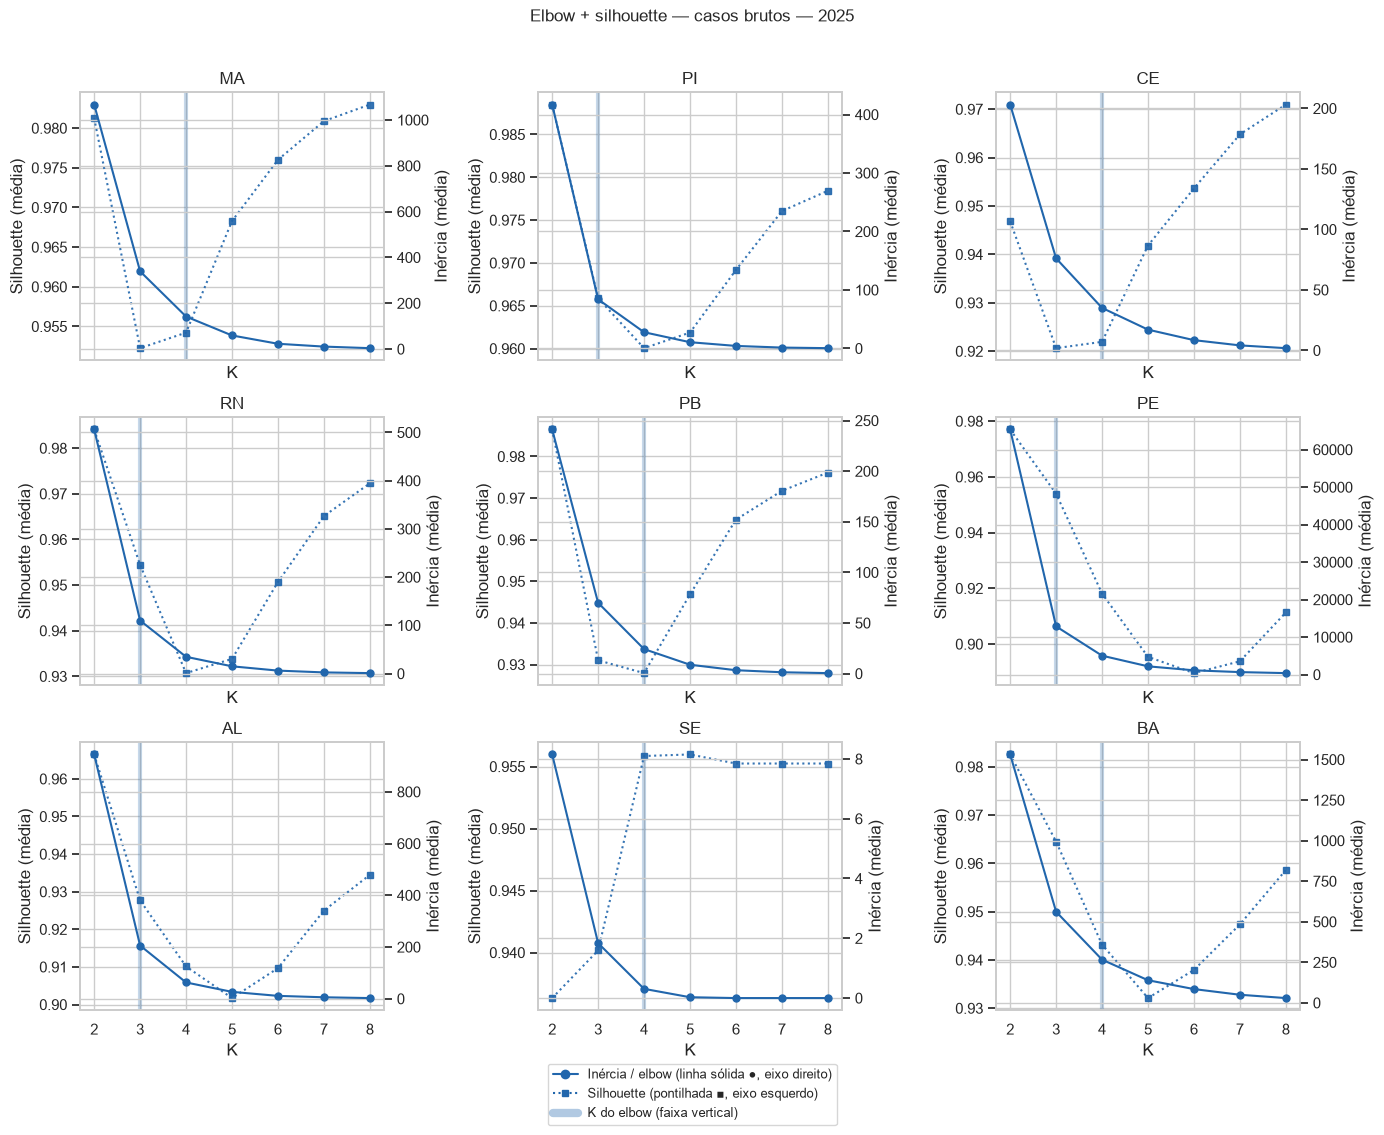

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)
axes_flat = axes.ravel()

for ax, uf in zip(axes_flat, NORDESTE):
    ax2 = ax.twinx()
    sub = agg[agg.uf == uf].sort_values("k")
    ax2.plot(sub.k, sub.inertia, color=COLOR, ls="-", marker="o", ms=5)
    ax.plot(sub.k, sub.silhouette, color=COLOR, ls=":", marker="s", ms=4, alpha=0.9)
    ek, _, _ = pick_k(sub)
    ax.axvline(ek, color=COLOR, alpha=0.25, lw=3)
    ax.set_title(uf)
    ax.set_xlabel("K")
    ax.set_ylabel("Silhouette (média)")
    ax2.set_ylabel("Inércia (média)")
    ax.set_xticks(K_RANGE)

legend_handles = [
    Line2D([0], [0], color=COLOR, ls="-", marker="o", ms=6, label="Inércia / elbow (linha sólida ●, eixo direito)"),
    Line2D([0], [0], color=COLOR, ls=":", marker="s", ms=5, label="Silhouette (pontilhada ■, eixo esquerdo)"),
    Line2D([0], [0], color=COLOR, alpha=0.35, lw=6, label="K do elbow (faixa vertical)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=1, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(f"Elbow + silhouette — casos brutos — {ANO}", y=1.01, fontsize=12)
fig.tight_layout()
fig.subplots_adjust(bottom=0.10)
plt.show()

## Heatmaps semana × K (silhouette)

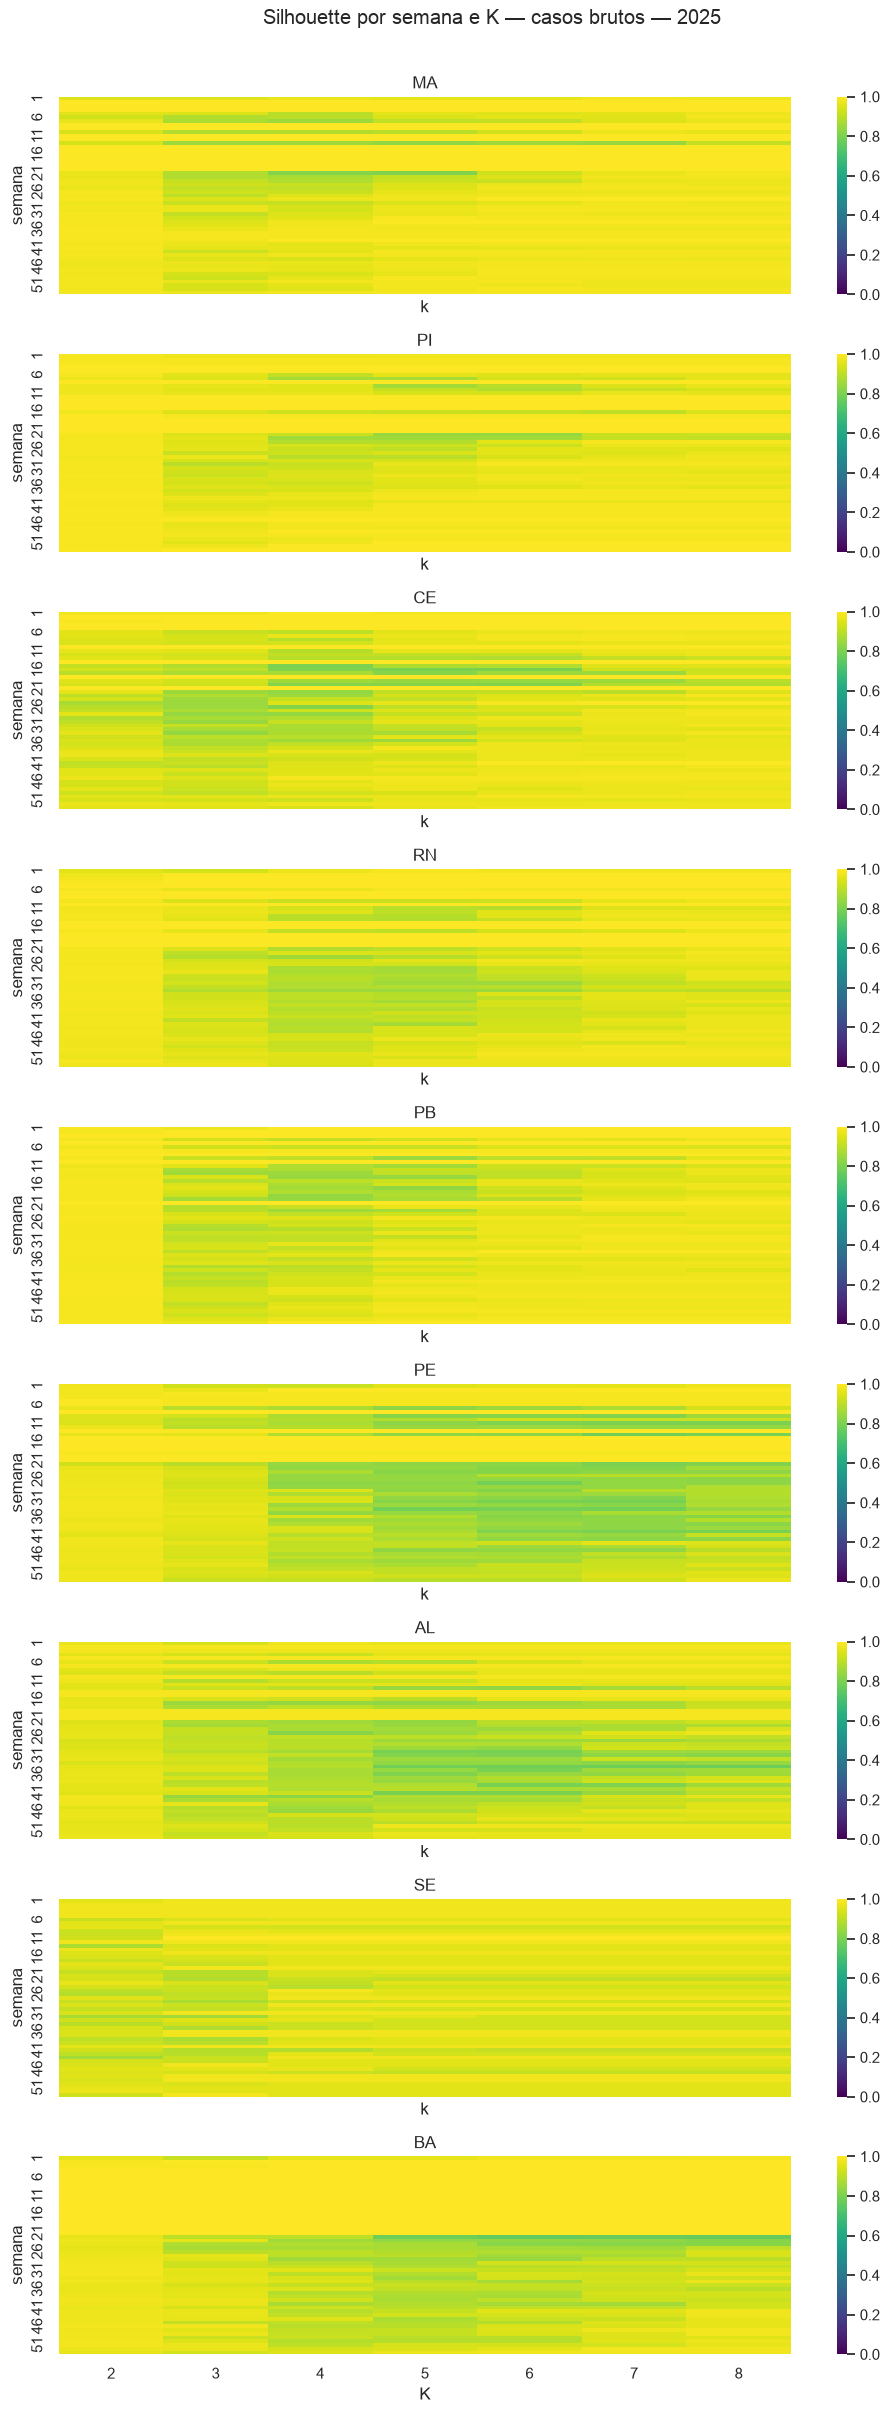

In [18]:
fig, axes = plt.subplots(len(NORDESTE), 1, figsize=(10, 24), sharex=True)

for ax, uf in zip(axes, NORDESTE):
    pivot = (
        metrics[metrics.uf == uf]
        .pivot_table(index="semana", columns="k", values="silhouette", aggfunc="mean")
        .sort_index()
    )
    sns.heatmap(pivot, ax=ax, cmap="viridis", vmin=0, vmax=1, cbar=True)
    ax.set_title(uf)
    ax.set_ylabel("semana")

axes[-1].set_xlabel("K")
fig.suptitle(f"Silhouette por semana e K — casos brutos — {ANO}", y=1.005)
fig.tight_layout()
plt.show()

## K por UF e recomendação global

In [19]:
per_uf_rows = []
for uf in NORDESTE:
    sub = agg[agg.uf == uf]
    k, sharp, sil = pick_k(sub)
    per_uf_rows.append({"uf": uf, "k_elbow": k, "elbow_nitidez": sharp, "silhouette": sil})

per_uf = pd.DataFrame(per_uf_rows)
counts = Counter(per_uf["k_elbow"])
mode_k, mode_n = counts.most_common(1)[0]
discordantes = per_uf[per_uf["k_elbow"] != mode_k]

print("K por UF:")
print(per_uf.to_string(index=False))
print("\n" + "=" * 60)
print(f"DEFAULT_K atual no backend: {DEFAULT_K}")
print(f"K recomendado (moda 9 UFs):  {mode_k}  ({mode_n}/9 estados)")
if discordantes.empty:
    print("Estados discordantes:          nenhum")
else:
    print("Estados discordantes:")
    for _, row in discordantes.iterrows():
        print(f"  {row['uf']}: K={int(row['k_elbow'])}")
print("=" * 60)
if mode_k == DEFAULT_K:
    print(f"Conclusão: K={DEFAULT_K} é consistente com elbow+silhouette em 2024.")
else:
    print(f"Conclusão: métricas sugerem K={mode_k}, diferente do DEFAULT_K={DEFAULT_K}.")

K por UF:
uf  k_elbow  elbow_nitidez  silhouette
MA        4       3.221221    0.954214
PI        3       3.797088    0.965866
CE        4       3.007391    0.921936
RN        3       3.705549    0.954403
PB        4       3.407006    0.927940
PE        3       3.849510    0.953941
AL        3       3.706628    0.927689
SE        4       3.038298    0.955849
BA        4       3.053883    0.943174

DEFAULT_K atual no backend: 4
K recomendado (moda 9 UFs):  4  (5/9 estados)
Estados discordantes:
  PI: K=3
  RN: K=3
  PE: K=3
  AL: K=3
Conclusão: K=4 é consistente com elbow+silhouette em 2024.


In [20]:
summary = agg.pivot_table(index="uf", columns="k", values="silhouette", aggfunc="mean")
summary

k,2,3,4,5,6,7,8
uf,,,,,,,
AL,0.966496,0.927689,0.910118,0.901713,0.909669,0.924957,0.934483
BA,0.982564,0.964495,0.943174,0.932101,0.937931,0.947358,0.958623
CE,0.946840,0.920631,0.921936,0.941838,0.953634,0.964795,0.970963
MA,0.981259,0.952259,0.954214,0.968285,0.976009,0.980884,0.982978
PB,0.986485,0.931015,0.927940,0.946844,0.964827,0.971743,0.976127
PE,0.976995,0.953941,0.918099,0.895411,0.889575,0.893809,0.911329
PI,0.988492,0.965866,0.960048,0.961869,0.969177,0.976050,0.978423
RN,0.984091,0.954403,0.930706,0.933820,0.950665,0.965112,0.972298
SE,0.936327,0.940171,0.955849,0.955975,0.955244,0.955244,0.955244


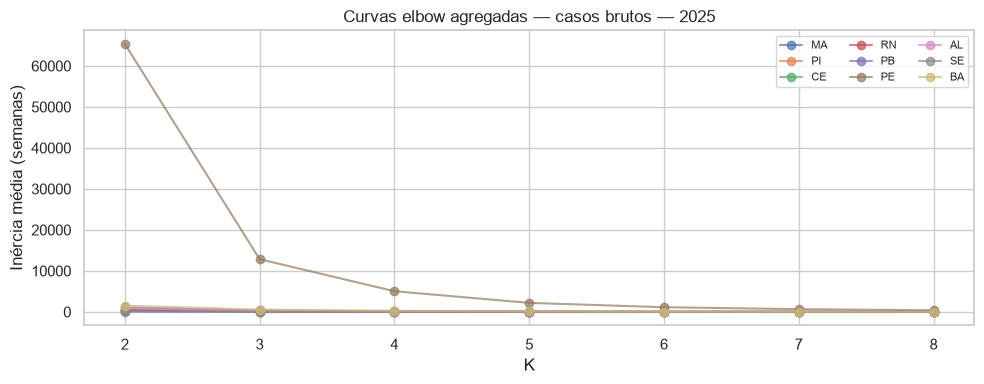

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
for uf in NORDESTE:
    sub = agg[agg.uf == uf].sort_values("k")
    ax.plot(sub.k, sub.inertia, marker="o", alpha=0.7, label=uf)
ax.set_xlabel("K")
ax.set_ylabel("Inércia média (semanas)")
ax.set_title(f"Curvas elbow agregadas — casos brutos — {ANO}")
ax.set_xticks(K_RANGE)
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plt.show()